In [5]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# SQLite database
conn = sqlite3.connect(":memory:")
cursor = conn.cursor()

# sample sales table
cursor.execute('''
CREATE TABLE online_sales (
    order_id TEXT,
    product TEXT,
    quantity INTEGER,
    unit_price REAL
);
''')

# Insert sample data
sample_data = [
    ('ORD001', 'Laptop', 2, 1000),
    ('ORD002', 'Phone', 5, 500),
    ('ORD003', 'Headphones', 10, 50),
    ('ORD004', 'Monitor', 3, 300),
    ('ORD005', 'Keyboard', 4, 550),
    ('ORD006', 'Mouse', 10, 450)
]

cursor.executemany('INSERT INTO online_sales VALUES (?, ?, ?, ?)', sample_data)
conn.commit()

In [16]:
df = pd.read_sql_query('''
    SELECT 
        product, 
        SUM(quantity) AS total_quantity,
        SUM(quantity * unit_price) AS total_revenue
    FROM online_sales
    GROUP BY product
''', conn)

print("Sales Summary:")
print(df)

Sales Summary:
      product  total_quantity  total_revenue
0  Headphones              10          500.0
1    Keyboard               4         2200.0
2      Laptop               2         2000.0
3     Monitor               3          900.0
4       Mouse              10         4500.0
5       Phone               5         2500.0


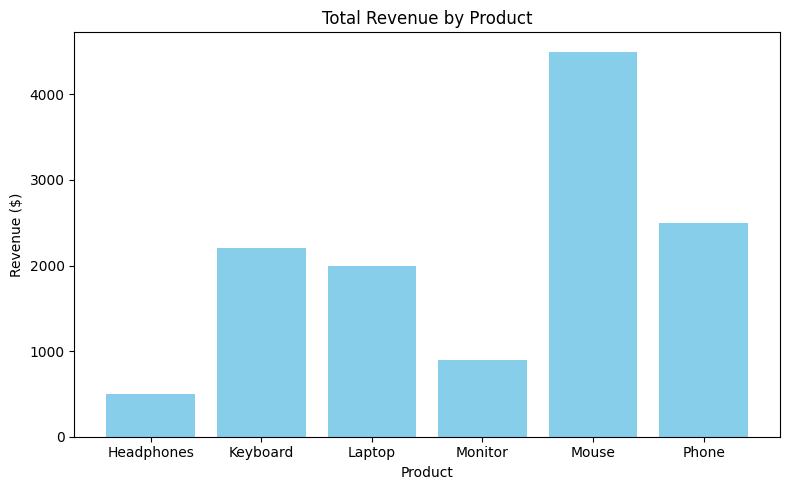

In [7]:
# total revenue by product
plt.figure(figsize=(8, 5))
plt.bar(df['product'], df['total_revenue'], color='skyblue')
plt.title('Total Revenue by Product')
plt.xlabel('Product')
plt.ylabel('Revenue ($)')
plt.tight_layout()
plt.show()

In [14]:
plt.savefig("sales_chart.png")



<Figure size 640x480 with 0 Axes>